In [10]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from utils import describe_data, plot_df_chart

In [11]:
# Import libraries
import numpy as np
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
symbol = "ES=F"
df = yf.download(symbol, period="max", interval="1D")

df.drop(columns=["Volume"], inplace=True)
df.columns = df.columns.droplevel("Ticker")
df.dropna(inplace=True)

df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open
Date,,,,
2026-05-18,7425.75,7454.25,7373.50,7410.00
2026-05-19,7378.00,7440.75,7354.25,7423.50
2026-05-20,7451.75,7458.00,7356.00,7377.00
2026-05-21,7466.00,7486.75,7407.50,7432.75
2026-05-22,7507.50,7524.00,7466.75,7467.00


In [13]:
df["Daily_return"] = 100 * (df["Close"] - df["Open"]) / df["Open"]

df.tail()

Price,Close,High,Low,Open,Daily_return
Date,,,,,
2026-05-18,7425.75,7454.25,7373.50,7410.00,0.212551
2026-05-19,7378.00,7440.75,7354.25,7423.50,-0.612918
2026-05-20,7451.75,7458.00,7356.00,7377.00,1.013285
2026-05-21,7466.00,7486.75,7407.50,7432.75,0.447345
2026-05-22,7507.50,7524.00,7466.75,7467.00,0.542387


In [14]:
N = 10

df["Cum_Daily_return"] = (
    df["Daily_return"]
    .shift(1)
    .rolling(N)
    .sum()
)

df.dropna(inplace=True)

df.head(10)

Price,Close,High,Low,Open,Daily_return,Cum_Daily_return
Date,,,,,,
2000-10-02,1456.25,1464.25,1447.50,1453.75,0.171969,-1.101131
2000-10-03,1441.50,1474.00,1438.75,1457.25,-1.080803,0.265923
2000-10-04,1450.25,1457.25,1432.50,1442.00,0.572122,-1.598793
2000-10-05,1456.00,1462.00,1447.25,1449.50,0.448430,-0.401142
2000-10-06,1426.25,1460.50,1411.50,1456.00,-2.043269,0.098300
2000-10-09,1416.50,1426.75,1408.00,1425.25,-0.613927,-2.890149
2000-10-10,1391.00,1424.50,1390.00,1417.50,-1.869489,-2.925648
2000-10-11,1378.50,1398.00,1361.75,1393.50,-1.076426,-3.563104
2000-10-12,1344.00,1387.75,1339.00,1379.50,-2.573396,-4.829974


In [15]:
plot_df_chart(
    df["Cum_Daily_return"],
    chart_type="bar",
    chart_title="Cumulative Daily returns",
    yaxis_title="Cumulative Daily Return (%)",
    width=1000,
    height=600,
)   

## Stats

In [16]:
df_stats, stats = describe_data(df["Cum_Daily_return"])

df_stats

,Value
Metric,
nobs,6474
Min %,-29.800467
Max %,23.246838
Mean %,0.419473
Median %,0.701165
Mode %,2.008366
Variance,10.92757
Skewness,-0.717193
Kurtosis,6.565715


In [17]:
x = 5

conditions = [
    df["Cum_Daily_return"] < -x,
    df["Cum_Daily_return"] > x
]

choices = ["bear", "bull"]

df["flag"] = np.select(conditions, choices, default="sideways")

df

Price,Close,High,Low,Open,Daily_return,Cum_Daily_return,flag
Date,,,,,,,
2000-10-02,1456.25,1464.25,1447.50,1453.75,0.171969,-1.101131,sideways
2000-10-03,1441.50,1474.00,1438.75,1457.25,-1.080803,0.265923,sideways
2000-10-04,1450.25,1457.25,1432.50,1442.00,0.572122,-1.598793,sideways
2000-10-05,1456.00,1462.00,1447.25,1449.50,0.448430,-0.401142,sideways
2000-10-06,1426.25,1460.50,1411.50,1456.00,-2.043269,0.098300,sideways
...,...,...,...,...,...,...,...
2026-05-18,7425.75,7454.25,7373.50,7410.00,0.212551,2.686191,sideways
2026-05-19,7378.00,7440.75,7354.25,7423.50,-0.612918,3.530935,sideways
2026-05-20,7451.75,7458.00,7356.00,7377.00,1.013285,2.108748,sideways


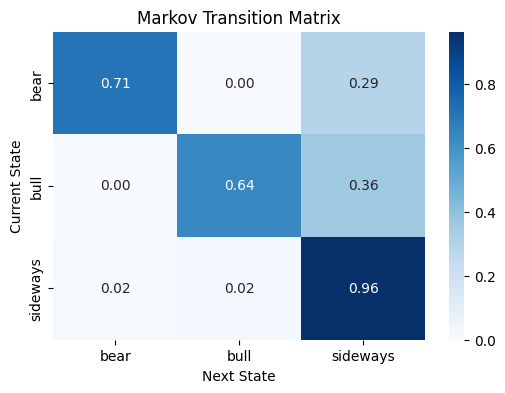

In [18]:
markov_matrix = pd.crosstab(
    df['flag'],
    df['flag'].shift(-1),
    normalize='index'
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    markov_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Markov Transition Matrix")
plt.xlabel("Next State")
plt.ylabel("Current State")

plt.show()